In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

In [2]:
df = pd.read_csv('../data/data_engineered_uber.csv')
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_day,...,trip_distance_km,pickup_to_center_km,dropoff_to_center_km,is_pickup_airport,is_dropoff_airport,is_airport,hour_sin,hour_cos,manhattan_distance,displacement_ratio
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,...,1.683323,2.495373,4.043831,0,0,0,-0.965926,0.258819,1.714050,1.018248
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,...,2.457590,3.393833,1.153325,0,0,0,-0.866025,0.500000,2.492505,1.014203
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,...,5.036377,2.526029,2.526542,0,0,0,-0.707107,0.707107,8.253405,1.638755
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,...,1.661683,3.736452,5.321257,0,0,0,0.866025,-0.500000,2.587743,1.557293
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,...,4.475450,5.324135,1.106473,0,0,0,-0.965926,-0.258819,7.239531,1.617606


<h2 style="color:green"> Correlation Analysis:   </h2>


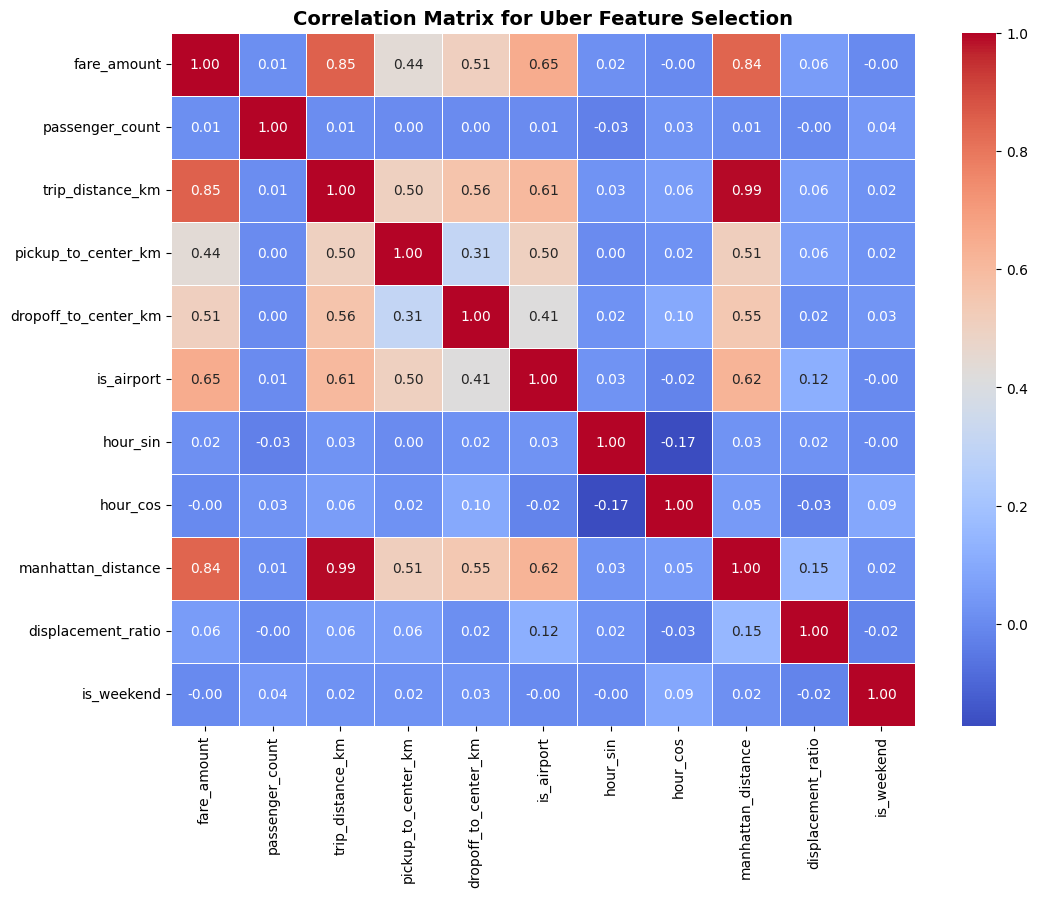

In [12]:
numerical_cols = [
    'fare_amount','passenger_count','trip_distance_km', 
    'pickup_to_center_km','dropoff_to_center_km','is_airport', 
    'hour_sin','hour_cos','manhattan_distance', 
    'displacement_ratio', 'is_weekend']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Uber Feature Selection", fontsize=14, fontweight='bold')
plt.show()

### Feature Selection Reference: Correlation Thresholds & Decisions

| Range of Correlation ($r$) | Relationship Strength | Expected Action / Decision in Feature Selection | Examples from Data |
| :--- | :--- | :--- | :--- |
| **$0.60$ to $1.00$** | **Strong Positive** | **Keep (Critical):** Fundamental predictors that drive the target variable. Cannot be removed. | `trip_distance_km`, `manhattan_distance` vs. `fare_amount` |
| **$0.30$ to $0.59$** | **Moderate** | **Keep (Informative):** Adds valuable contextual patterns and refinements to the model. | `is_airport`, `pickup_to_center_km` vs. `fare_amount` |
| **$0.00$ to $0.10$** | **Very Weak / None** | **Drop Candidate:** Has no statistical impact on the price. Safe to eliminate to simplify the model. | `passenger_count` vs. `fare_amount` |
| ** Above $0.85$** <br>*(Between 2 features)* | **Multi-Collinearity** | **Redundancy Alert:** Two features provide identical information. Keep only one (e.g., Manhattan) to prevent overfitting and speed up training. | `trip_distance_km` vs. `manhattan_distance` |

> **Quick Note for Evaluation:** Look at the `fare_amount` row/column first to filter out useless features, then check the intersections of the remaining features to eliminate redundant twins.

### Feature Selection Report & Final Documented Set

Based on the Correlation Matrix analysis, the following decisions were made to optimize the feature set, reduce redundancy (Multi-Collinearity), and improve model training efficiency:

#### 1. Dropped Features:
* **`passenger_count` (Correlation = 0.01):** Removed due to extremely weak linear relationship with `fare_amount`. The number of passengers does not statistically impact pricing.
* **`trip_distance_km` (Multi-Collinearity Alert):** This feature has a **99% (0.99)** correlation with `manhattan_distance`. To prevent redundant data feeding, it is eliminated, retaining `manhattan_distance` as it represents NYC’s grid-like driving paths more accurately.

#### 2. Retained Features:
* **`manhattan_distance` (0.84):** Primary driver for trip fares.
* **`is_airport` (0.65):** Captures high flat-rate zones and airport transit pricing patterns.
* **`dropoff_to_center_km` (0.51) & `pickup_to_center_km` (0.44):** Captures distance-from-core-city dynamics.
* **`hour_sin` & `hour_cos`:** Retained to allow non-linear ensemble models to capture daily cyclical rush hours and peak continuous time boundaries.
* **`displacement_ratio`:** Retained to provide insights into route complexity and non-linear traffic detours.

**Final Selected Feature Set for Training:** `['manhattan_distance', 'is_airport', 'dropoff_to_center_km', 'pickup_to_center_km', 'hour_sin', 'hour_cos', 'displacement_ratio']`

<h2 style="color:green"> Mutual Information:  </h2>


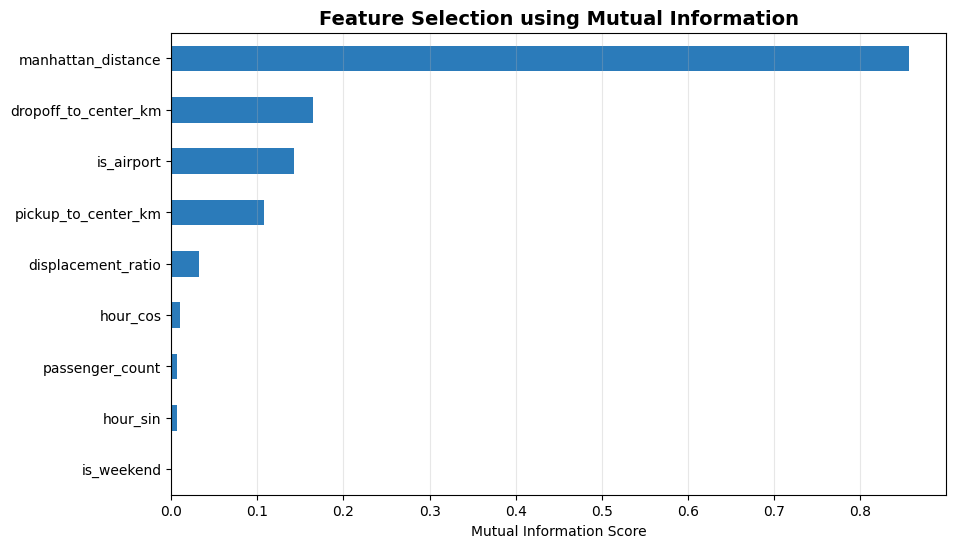

In [13]:
numerical_cols = ['passenger_count', 'pickup_to_center_km',
                  'dropoff_to_center_km','is_airport', 
                  'hour_sin','hour_cos',
                  'manhattan_distance','displacement_ratio','is_weekend']
x_mi = df[numerical_cols].fillna(0)
y_mi = df['fare_amount']

mi_scores = mutual_info_regression(x_mi , y_mi , random_state=42)
mi_scores_series = pd.Series(mi_scores, index=numerical_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='#2b7bba')
plt.xlabel("Mutual Information Score")
plt.title("Feature Selection using Mutual Information", fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Feature Selection Insight: Mutual Information Analysis

To capture both linear and non-linear dependencies between our engineered features and the target variable (`fare_amount`), we computed the **Mutual Information (MI) Regression Scores**. Unlike standard correlation, MI measures the amount of information shared between variables, effectively quantifying how much knowing a feature reduces uncertainty about the fare.

#### Key Observations from the MI Plot:
* **Dominant Predictors:** `manhattan_distance` shares the highest mutual information with the fare, confirming its status as the most critical structural feature for the model.
* **Non-Linear Value:** Features like `is_airport`, `pickup_to_center_km`, and the cyclical time components (`hour_sin`, `hour_cos`) show solid non-zero MI scores. This proves they carry unique contextual distributions that linear metrics might underrepresent but tree-based algorithms can highly exploit.
* **Zero-Information Baseline:** The `passenger_count` feature scores extremely close to 0.0, statistically confirming that the number of passengers holds zero informational dependency relative to Uber pricing structures.

**Conclusion:** The MI analysis perfectly aligns with our correlation findings, providing solid mathematical justification for dropping obsolete features and retaining highly informative behavioral ones.